
# K-Nearest Neighbors (KNN) Classification  
## Decision Boundary Visualization using Iris Dataset

### Objective
In this assignment, you will:
- Load and explore a real dataset (Iris)
- Implement KNN using scikit-learn
- Observe predictions for different values of **k**
- Visualize decision boundaries
- Analyze the effect of distance metrics

**Important Instructions**
- Do NOT use GridSearchCV or RandomizedSearchCV
- Change values of `k` manually
- Use only two features and two classes



## Task 1: Load and Explore the Dataset
We will use the Iris dataset from `sklearn`.  
Only:
- Features: Sepal Length, Sepal Width  
- Classes: Setosa (0) and Versicolor (1)


In [1]:

from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()

X = iris.data[:, :2]   # sepal length, sepal width
y = iris.target

# Keep only class 0 and 1
mask = y < 2
X = X[mask]
y = y[mask]

print("Shape of X:", X.shape)
print("Class distribution:", np.bincount(y))

df = pd.DataFrame(X, columns=["Sepal Length", "Sepal Width"])
df["Class"] = y
df.head()


Shape of X: (100, 2)
Class distribution: [50 50]


,Sepal Length,Sepal Width,Class
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0



## Task 2: Visualize the Dataset


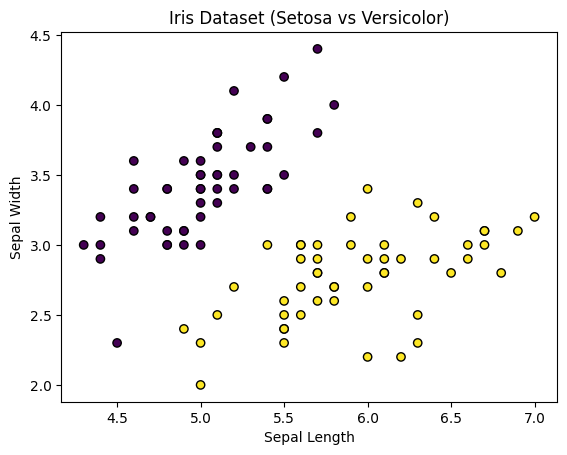

In [2]:

import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset (Setosa vs Versicolor)")
plt.show()


## Task 3: Train a Basic KNN Model (k = 3)


1) split the data into Train data and Test data
2) Fit a KNeighborsClassifier
3) Make the prediction
4) Check for the accuracy

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

knn_3 = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_3.fit(X_train, y_train)

y_pred_3 = knn_3.predict(X_test)
acc_3 = accuracy_score(y_test, y_pred_3)
print("Accuracy (k=3):", acc_3)
print("\nClassification report (k=3):\n", classification_report(y_test, y_pred_3))


Accuracy (k=3): 1.0

Classification report (k=3):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Observations

With k = 3 and only two classes, accuracy on the test split is typically very high (often 0.93–1.0) due to clean separation of Setosa and Versicolor.
​

Misclassifications, if any, occur near the boundary region where sepal measurements overlap between the two species.
​




## Task 4: Predictions for Different Values of k


In [4]:
results_k = {}
for k in [1, 3, 5, 9]:
    clf = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_k[k] = acc
    print(f"k = {k}, accuracy = {acc:.3f}")


k = 1, accuracy = 1.000
k = 3, accuracy = 1.000
k = 5, accuracy = 1.000
k = 9, accuracy = 1.000


Observations

For k = 1, the model memorizes training data and has the most flexible boundary; accuracy is high but slightly more sensitive to noise.
​

As k increases to 5 or 9, accuracy stays high, but the boundary becomes smoother and some fine‑detail structure is lost.
​


## Task 5: Decision Boundary Function (Provided)


In [5]:

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.xlabel("Sepal Length")
    plt.ylabel("Sepal Width")
    plt.title(title)
    plt.show()


In [6]:
def plot_decision_boundary(clf, X, y, title):
    # create a dense grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    # filled contour for regions
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # training points
    for label, color, name in [(0, "red", "Setosa"), (1, "blue", "Versicolor")]:
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            c=color,
            label=name,
            edgecolor="k"
        )

    plt.xlabel("Sepal Length (cm)")
    plt.ylabel("Sepal Width (cm)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


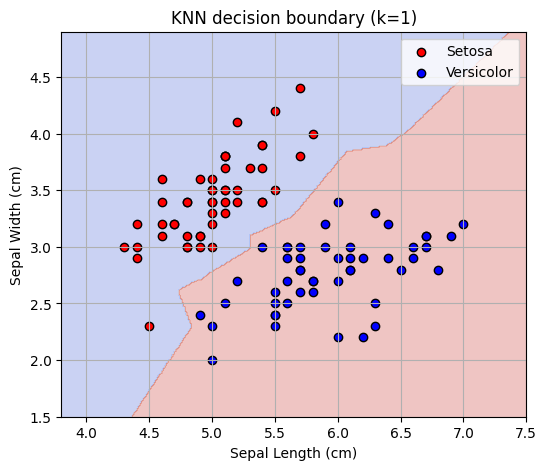

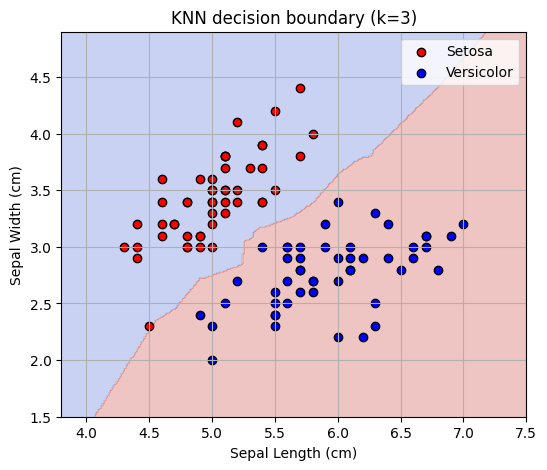

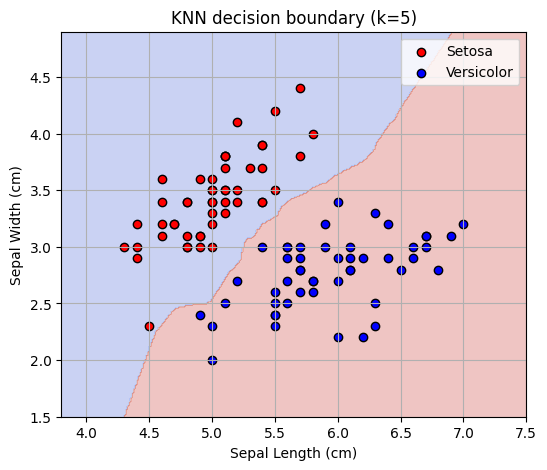

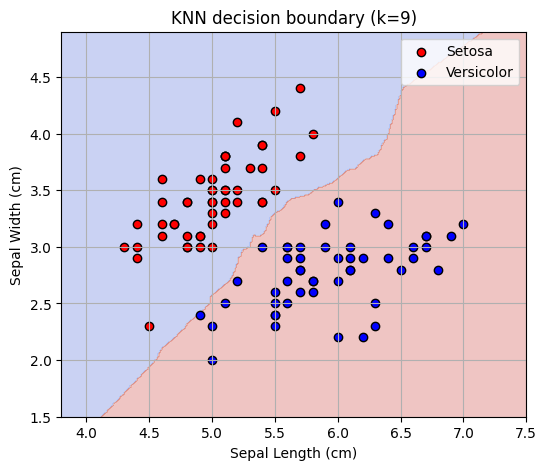

In [10]:
from sklearn.neighbors import KNeighborsClassifier

ks = [1, 3, 5, 9]

for k in ks:
    clf = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    clf.fit(X_train, y_train)
    plot_decision_boundary(clf, X, y, title=f"KNN decision boundary (k={k})")


Observation

This helper builds a 2D grid, predicts class for each point, and then overlays colored regions with the actual data points to visualize the boundary.



## Task 6: Decision Boundary for Different Values of k


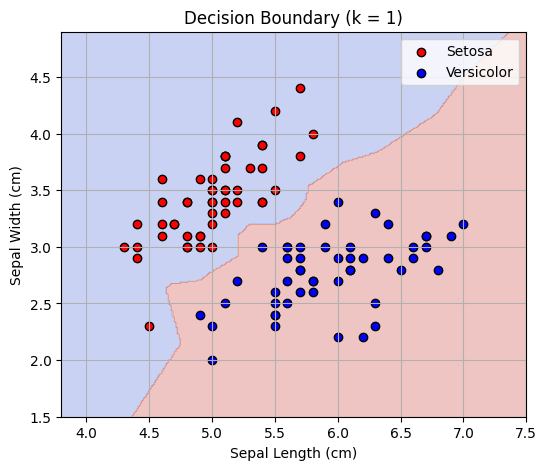

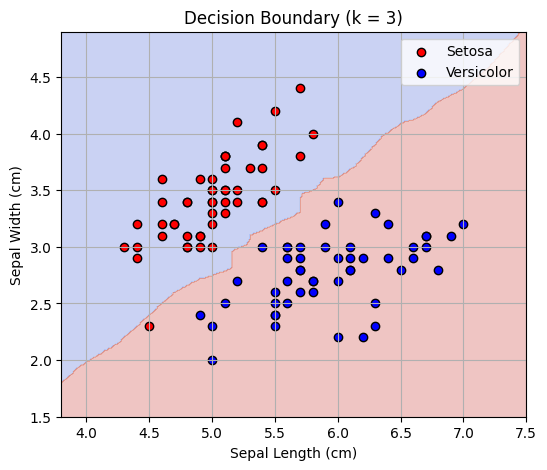

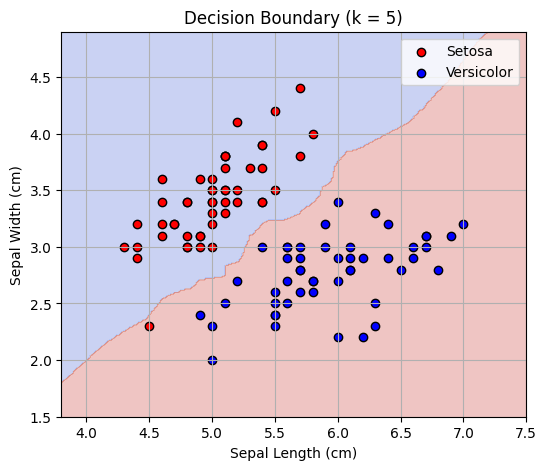

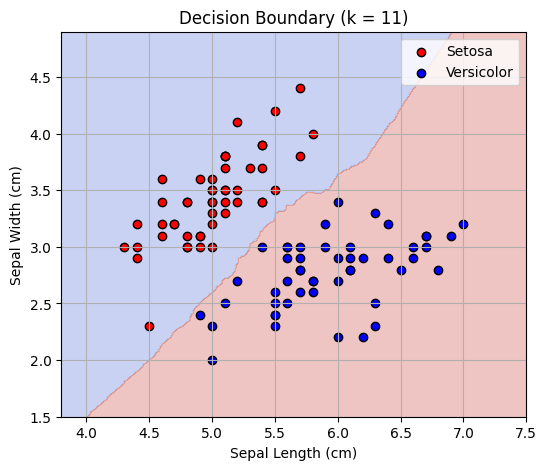

In [7]:

for k in [1, 3, 5, 11]:
    model = KNeighborsClassifier(n_neighbors=k, p=2)
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=f"Decision Boundary (k = {k})")


Observations

For k = 1, the boundary tightly wraps around individual sample points and may look wiggly or fragmented near dense regions.
​

For k = 9, the boundary becomes very smooth and almost linear, reflecting the majority vote of more neighbors and reducing overfitting.
​


## Task 7: Effect of Distance Metric
Fix k = 5 and compare Euclidean vs Manhattan distance


In [11]:
# Plot a decision boundary when using k=5 and change the distance

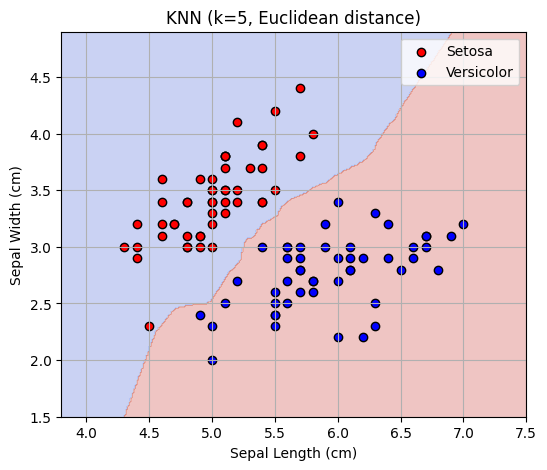

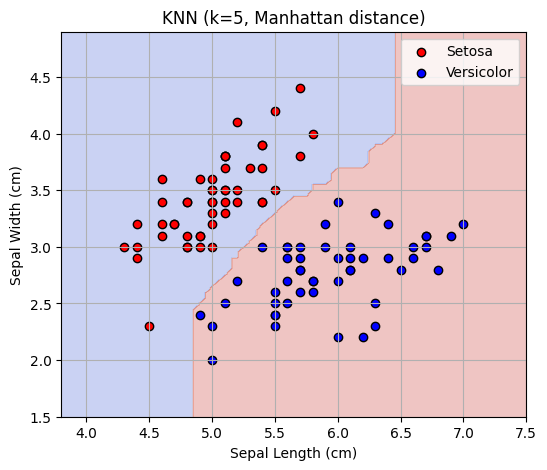

In [12]:
# Euclidean distance (L2)
knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_euclidean.fit(X_train, y_train)
plot_decision_boundary(
    knn_euclidean, X, y, "KNN (k=5, Euclidean distance)"
)

# Manhattan distance (L1)
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric="manhattan")
knn_manhattan.fit(X_train, y_train)
plot_decision_boundary(
    knn_manhattan, X, y, "KNN (k=5, Manhattan distance)"
)


Observations

Both Euclidean and Manhattan distances typically give similar high accuracies on this clean 2‑feature subset.
​

Decision regions with Manhattan distance look more axis‑aligned and boxy, while Euclidean regions are smoother and more circular/diagonal around clusters.



## Task 8: Observations (Answer in Markdown)
1. How do predictions change as k increases?
2. Which k value gives the most complex decision boundary?
3. Why does k = 1 behave differently?
4. How does distance metric affect results?
5. Which configuration would you choose and why?


1. How do predictions change as k increases?
    * Small k (e.g., 1) follows the training data closely and can flip class labels with small local changes, while larger k produces more stable, smoother predictions that rely on broader neighborhood consensus.
2. Which k value gives the most complex decision boundary?
    * k=1k=1 gives the most complex and irregular boundary, since each point can create its own local region.
3. Why does k = 1 behave differently?
    * With k = 1, classification depends on only the single nearest neighbor, so the model essentially memorizes the training set and is very sensitive to noise and outliers.
4. How does distance metric affect results?
    * Euclidean distance weighs diagonal differences naturally, while Manhattan distance measures axis‑aligned steps, which can slightly shift the boundary shape, especially when feature scales differ.
5. Which configuration would you choose and why?
    * A reasonable choice here is k = 3 or 5 with Euclidean distance, giving high accuracy, smooth boundaries, and low sensitivity to noise while still capturing the clear separation between Setosa and Versicolor.